### Creating a qbits object for Ising Calculation

In [56]:
import matplotlib.pyplot as plt # for plotting
import numpy as np              # numpy 
import qse                      # import the qse
import pulser

#### 1-D qubits object

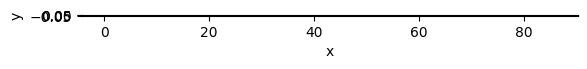

In [48]:
Omega_max = 2.0 * 2 * np.pi
U = Omega_max / 2.0

delta_0 = -6 * U
delta_f = 2 * U

t_rise = 252
t_fall = 500

t_sweep = (delta_f - delta_0) / (2 * np.pi * 10) * 1000

# We extract the reference blockade radius from pulser here
R_interatomic = qse.calc.blockade_radius(U)

L = 12     # lattice size

# Now we generate the qbits object that represents 1D lattice with r0 as lattice spaceing

r0 = 0.8 * R_interatomic
# keeping r0 a bit below blockade radius keeps the nearest neighbours antiferromagnetic

q1d = qse.lattices.chain(r0, L)
q1d.draw()

In [49]:
amplitude_afm = pulser.CompositeWaveform(
    pulser.waveforms.RampWaveform(t_rise, 0.0, Omega_max),
    pulser.waveforms.ConstantWaveform(t_sweep,Omega_max),
    pulser.waveforms.RampWaveform(t_fall, Omega_max, 0.0)
    )
# up ramp, constant, downramp waveform

detuning_afm = pulser.CompositeWaveform(
    pulser.waveforms.ConstantWaveform(t_rise,delta_0),
    pulser.waveforms.RampWaveform(t_sweep, delta_0, delta_f),
    pulser.waveforms.ConstantWaveform(t_fall,delta_f)
    )
# corresponding waveform for detuning


In [50]:
t_rise = 2000
Omega_max = 2.3 * 2 * np.pi
pcalc = qse.calc.Pulser(
    qbits = q1d,
    amplitude = amplitude_afm,
    detuning = detuning_afm)


/Users/rajarshi/miniforge/envs/jb/lib/python3.12/site-packages/qse/qbits.py:1186: UserWarning: 1D system passed, adding a y axis.
  warnings.warn("1D system passed, adding a y axis.")


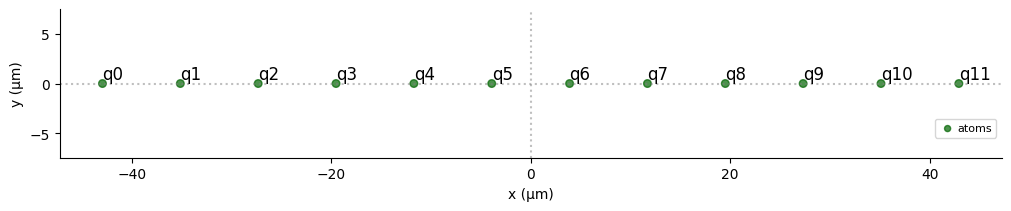

In [51]:
pcalc.register.draw()

In [52]:
pcalc.build_sequence()
pcalc.calculate()

10.1%. Run time:   0.04s. Est. time left: 00:00:00:00
20.0%. Run time:   0.08s. Est. time left: 00:00:00:00
30.0%. Run time:   0.12s. Est. time left: 00:00:00:00
40.0%. Run time:   0.17s. Est. time left: 00:00:00:00
50.0%. Run time:   0.22s. Est. time left: 00:00:00:00
60.1%. Run time:   0.25s. Est. time left: 00:00:00:00
70.0%. Run time:   0.30s. Est. time left: 00:00:00:00
80.0%. Run time:   0.34s. Est. time left: 00:00:00:00
90.0%. Run time:   0.38s. Est. time left: 00:00:00:00
100.0%. Run time:   0.42s. Est. time left: 00:00:00:00
Total run time:   0.42s
time in compute and simulation = 6.819699287414551 s.


In [53]:
results = pcalc.results

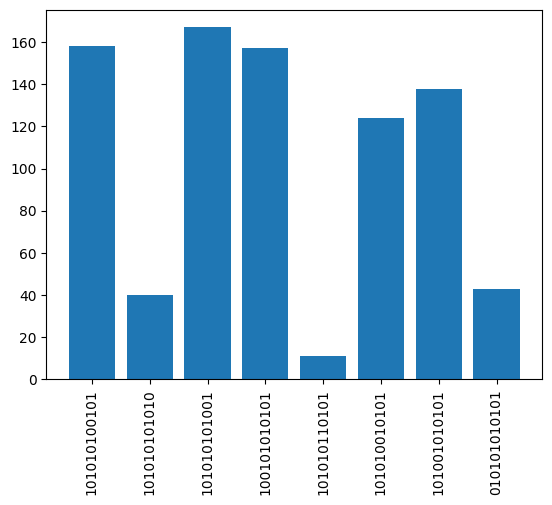

In [54]:
count = results.sample_final_state()

most_freq = {k: v for k, v in count.items() if v > 10}
plt.bar(list(most_freq.keys()), list(most_freq.values()))
plt.xticks(rotation="vertical")
plt.show()

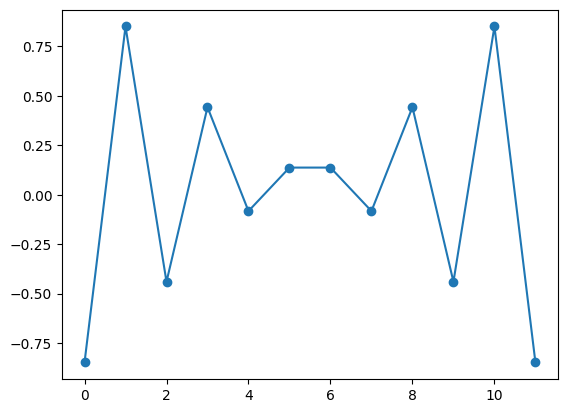

In [55]:
plt.plot(pcalc.spins.dot([0, 0, 1]), 'o-') # overlap with z-axis